### PROJECT : Unstructured Text Data Cleaning

In [3]:
#import require library
import pandas as pd

In [14]:
#1. Load Row Data
df=pd.read_csv(r"C:\Users\Sneha\Downloads\houses.txt",on_bad_lines="skip",header=None,skiprows=[0,1,2])
df.head(20)

,0,1,2
0,...',Wiley,1980. N.B. Various transformations are used...
1,pages 244-261 of the latter.,NaN,NaN
2,Variables in order:,NaN,NaN
3,CRIM per capita crime rate by town,NaN,NaN
4,ZN proportion of residential land zoned...,000 sq.ft.,NaN
5,INDUS proportion of non-retail business ac...,NaN,NaN
6,CHAS Charles River dummy variable (= 1 if...,NaN,NaN
7,NOX nitric oxides concentration (parts p...,NaN,NaN
8,RM average number of rooms per dwelling,NaN,NaN
9,AGE proportion of owner-occupied units b...,NaN,NaN


### Extract header section

In [15]:
# Extract column names (header section)
header_row=df.iloc[3:17]
header_row

,0,1,2
3,CRIM per capita crime rate by town,NaN,NaN
4,ZN proportion of residential land zoned...,000 sq.ft.,NaN
5,INDUS proportion of non-retail business ac...,NaN,NaN
6,CHAS Charles River dummy variable (= 1 if...,NaN,NaN
7,NOX nitric oxides concentration (parts p...,NaN,NaN
8,RM average number of rooms per dwelling,NaN,NaN
9,AGE proportion of owner-occupied units b...,NaN,NaN
10,DIS weighted distances to five Boston em...,NaN,NaN
11,RAD index of accessibility to radial hig...,NaN,NaN
12,TAX full-value property-tax rate per $10,000,NaN


In [16]:
header=header_row[0].str.split(" ",expand=True)[1]
header

3        CRIM
4          ZN
5       INDUS
6        CHAS
7         NOX
8          RM
9         AGE
10        DIS
11        RAD
12        TAX
13    PTRATIO
14          B
15      LSTAT
16       MEDV
Name: 1, dtype: object

In [17]:
#Extract actual data (after header)
data=df.iloc[17:]
data

,0,1,2
17,0.00632 18.00 2.310 0 0.5380 6.5750 65...,NaN,NaN
18,396.90 4.98 24.00,NaN,NaN
19,0.02731 0.00 7.070 0 0.4690 6.4210 78...,NaN,NaN
20,396.90 9.14 21.60,NaN,NaN
21,0.02729 0.00 7.070 0 0.4690 7.1850 61...,NaN,NaN
...,...,...,...
1024,396.90 5.64 23.90,NaN,NaN
1025,0.10959 0.00 11.930 0 0.5730 6.7940 89...,NaN,NaN
1026,393.45 6.48 22.00,NaN,NaN
1027,0.04741 0.00 11.930 0 0.5730 6.0300 80...,NaN,NaN


### Handle Multiple Line Records using iloc (Each Record =2 rows)

In [18]:
data_row1=data.iloc[:1028:2]
data_row1

,0,1,2
17,0.00632 18.00 2.310 0 0.5380 6.5750 65...,NaN,NaN
19,0.02731 0.00 7.070 0 0.4690 6.4210 78...,NaN,NaN
21,0.02729 0.00 7.070 0 0.4690 7.1850 61...,NaN,NaN
23,0.03237 0.00 2.180 0 0.4580 6.9980 45...,NaN,NaN
25,0.06905 0.00 2.180 0 0.4580 7.1470 54...,NaN,NaN
...,...,...,...
1019,0.06263 0.00 11.930 0 0.5730 6.5930 69...,NaN,NaN
1021,0.04527 0.00 11.930 0 0.5730 6.1200 76...,NaN,NaN
1023,0.06076 0.00 11.930 0 0.5730 6.9760 91...,NaN,NaN
1025,0.10959 0.00 11.930 0 0.5730 6.7940 89...,NaN,NaN


In [19]:
data_1=data_row1[0].str.split("  ",expand=True)# Split Columns using Multiple Spaces
data_1.reset_index(inplace=True)
data_1

,index,0,1,2,3,4,5,6,7,8,9,10
0,17,0.00632,18.00,2.310,0,0.5380,6.5750,65.20,4.0900,1,296.0,15.30
1,19,0.02731,0.00,7.070,0,0.4690,6.4210,78.90,4.9671,2,242.0,17.80
2,21,0.02729,0.00,7.070,0,0.4690,7.1850,61.10,4.9671,2,242.0,17.80
3,23,0.03237,0.00,2.180,0,0.4580,6.9980,45.80,6.0622,3,222.0,18.70
4,25,0.06905,0.00,2.180,0,0.4580,7.1470,54.20,6.0622,3,222.0,18.70
...,...,...,...,...,...,...,...,...,...,...,...,...
501,1019,0.06263,0.00,11.930,0,0.5730,6.5930,69.10,2.4786,1,273.0,21.00
502,1021,0.04527,0.00,11.930,0,0.5730,6.1200,76.70,2.2875,1,273.0,21.00
503,1023,0.06076,0.00,11.930,0,0.5730,6.9760,91.00,2.1675,1,273.0,21.00
504,1025,0.10959,0.00,11.930,0,0.5730,6.7940,89.30,2.3889,1,273.0,21.00


In [20]:
data_1.drop(columns="index",inplace=True)

In [21]:
data_1.isnull().value_counts()

0      1      2      3      4      5      6      7      8      9      10   
False  False  False  False  False  False  False  False  False  False  False    506
Name: count, dtype: int64

In [22]:
data

,0,1,2
17,0.00632 18.00 2.310 0 0.5380 6.5750 65...,NaN,NaN
18,396.90 4.98 24.00,NaN,NaN
19,0.02731 0.00 7.070 0 0.4690 6.4210 78...,NaN,NaN
20,396.90 9.14 21.60,NaN,NaN
21,0.02729 0.00 7.070 0 0.4690 7.1850 61...,NaN,NaN
...,...,...,...
1024,396.90 5.64 23.90,NaN,NaN
1025,0.10959 0.00 11.930 0 0.5730 6.7940 89...,NaN,NaN
1026,393.45 6.48 22.00,NaN,NaN
1027,0.04741 0.00 11.930 0 0.5730 6.0300 80...,NaN,NaN


In [23]:
#Same Process For Data Row 2
data_row2=data.iloc[1:1029:2]
data_row2

,0,1,2
18,396.90 4.98 24.00,NaN,NaN
20,396.90 9.14 21.60,NaN,NaN
22,392.83 4.03 34.70,NaN,NaN
24,394.63 2.94 33.40,NaN,NaN
26,396.90 5.33 36.20,NaN,NaN
...,...,...,...
1020,391.99 9.67 22.40,NaN,NaN
1022,396.90 9.08 20.60,NaN,NaN
1024,396.90 5.64 23.90,NaN,NaN
1026,393.45 6.48 22.00,NaN,NaN


In [24]:
data_2=data_row2[0].str.split("  ",expand=True)
data_2

,0,1,2,3,4
18,,396.90,4.98,24.00,None
20,,396.90,9.14,21.60,None
22,,392.83,4.03,34.70,None
24,,394.63,2.94,33.40,None
26,,396.90,5.33,36.20,None
...,...,...,...,...,...
1020,,391.99,9.67,22.40,None
1022,,396.90,9.08,20.60,None
1024,,396.90,5.64,23.90,None
1026,,393.45,6.48,22.00,None


In [25]:
data_2.drop(columns=[0,4],inplace=True)#drop unwanted columns
data_2

,1,2,3
18,396.90,4.98,24.00
20,396.90,9.14,21.60
22,392.83,4.03,34.70
24,394.63,2.94,33.40
26,396.90,5.33,36.20
...,...,...,...
1020,391.99,9.67,22.40
1022,396.90,9.08,20.60
1024,396.90,5.64,23.90
1026,393.45,6.48,22.00


In [26]:
data_2.reset_index(inplace=True)


In [27]:
data_2.drop(columns="index",inplace=True)
data_2

,1,2,3
0,396.90,4.98,24.00
1,396.90,9.14,21.60
2,392.83,4.03,34.70
3,394.63,2.94,33.40
4,396.90,5.33,36.20
...,...,...,...
501,391.99,9.67,22.40
502,396.90,9.08,20.60
503,396.90,5.64,23.90
504,393.45,6.48,22.00


# Combine Both Parts to Form complete Records

In [28]:
finaldata=data_1.join(data_2,rsuffix="data2") #use resuffix for avoiding data overlaping
finaldata.shape

(506, 14)

# assign Column Names 

In [29]:
header.shape #hence columns count match 

(14,)

In [30]:
finaldata.columns=header

# Final Data Check

In [31]:
finaldata

1,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.00,2.310,0,0.5380,6.5750,65.20,4.0900,1,296.0,15.30,396.90,4.98,24.00
1,0.02731,0.00,7.070,0,0.4690,6.4210,78.90,4.9671,2,242.0,17.80,396.90,9.14,21.60
2,0.02729,0.00,7.070,0,0.4690,7.1850,61.10,4.9671,2,242.0,17.80,392.83,4.03,34.70
3,0.03237,0.00,2.180,0,0.4580,6.9980,45.80,6.0622,3,222.0,18.70,394.63,2.94,33.40
4,0.06905,0.00,2.180,0,0.4580,7.1470,54.20,6.0622,3,222.0,18.70,396.90,5.33,36.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.00,11.930,0,0.5730,6.5930,69.10,2.4786,1,273.0,21.00,391.99,9.67,22.40
502,0.04527,0.00,11.930,0,0.5730,6.1200,76.70,2.2875,1,273.0,21.00,396.90,9.08,20.60
503,0.06076,0.00,11.930,0,0.5730,6.9760,91.00,2.1675,1,273.0,21.00,396.90,5.64,23.90
504,0.10959,0.00,11.930,0,0.5730,6.7940,89.30,2.3889,1,273.0,21.00,393.45,6.48,22.00


### Data Validation Check

In [32]:
finaldata.isnull().sum()

1
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [33]:
finaldata.duplicated().sum()

np.int64(0)

In [35]:
print("--- Missing Values Per Column ---")
print(finaldata.isnull().sum())
print("\n--- Total Duplicate Rows ---")
print(finaldata.duplicated().sum())
print("\n--- Data Structure Overview ---")
finaldata.info()

--- Missing Values Per Column ---
1
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

--- Total Duplicate Rows ---
0

--- Data Structure Overview ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   CRIM     506 non-null    object
 1   ZN       506 non-null    object
 2   INDUS    506 non-null    object
 3   CHAS     506 non-null    object
 4   NOX      506 non-null    object
 5   RM       506 non-null    object
 6   AGE      506 non-null    object
 7   DIS      506 non-null    object
 8   RAD      506 non-null    object
 9   TAX      506 non-null    object
 10  PTRATIO  506 non-null    object
 11  B        506 non-null    object
 12  LSTAT    506 non-null    object
 13  MEDV     506 non-null    object
dtypes:

In [36]:
# Convert all columns to numeric, turning any remaining uncleaned text into NaN
finaldata = finaldata.apply(pd.to_numeric, errors='coerce')

# Verify the changes
finaldata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        498 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [37]:
# Fill the missing values in column 'B' with its median
finaldata['B'] = finaldata['B'].fillna(finaldata['B'].median())

# Verify that there are absolutely no null values left
print(finaldata.isnull().sum())

1
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


# Save Cleaned data

In [38]:
finaldata.to_csv(r"C:\Users\Sneha\Desktop\unstructured-data-cleaning-project\cleaned_housing_data.csv", index=False)

### Exploratory data analysis (EDA)

In [41]:
# Calculate correlations
correlation_matrix = finaldata.corr()

# Look specifically at what correlates most with home prices (MEDV)
print(correlation_matrix['MEDV'].sort_values(ascending=False))

1
MEDV       1.000000
RM         0.697452
ZN         0.357158
B          0.303470
DIS        0.242098
CHAS       0.173235
RAD       -0.364358
AGE       -0.370069
CRIM      -0.383956
NOX       -0.416134
TAX       -0.453461
INDUS     -0.474960
PTRATIO   -0.501716
LSTAT     -0.715170
Name: MEDV, dtype: float64


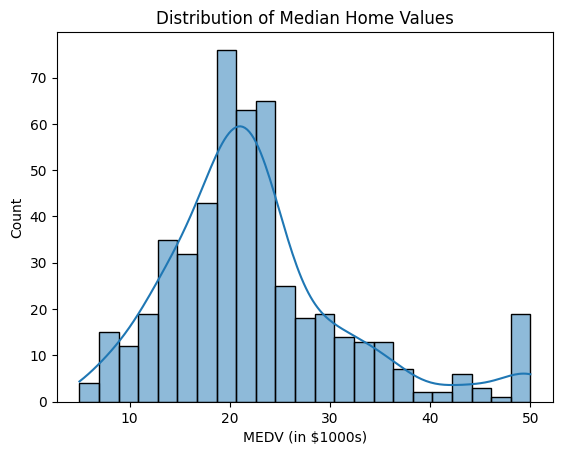

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(finaldata['MEDV'], kde=True)
plt.title('Distribution of Median Home Values')
plt.xlabel('MEDV (in $1000s)')
plt.show()

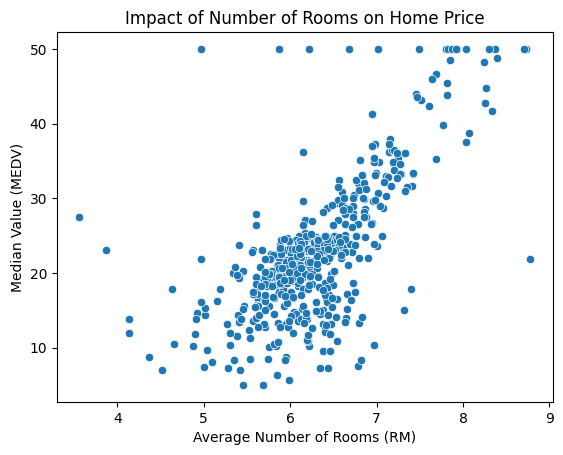

In [40]:
sns.scatterplot(x='RM', y='MEDV', data=finaldata)
plt.title('Impact of Number of Rooms on Home Price')
plt.xlabel('Average Number of Rooms (RM)')
plt.ylabel('Median Value (MEDV)')
plt.show()